# Coordinated Activity Detection

Find unusually synchronized content sharing in a synthetic public-post dataset.

**Safety and scope:** This notebook uses deterministic synthetic data and makes no network requests. Its results are analytical leads, not attribution or identity claims.

## Goal

Generate transparent coordination leads without inferring identity, intent, or authenticity from timing alone.


## Setup

The workflow runs offline with NumPy and Pandas. Parameters and source-like fields are visible so the analysis can be reviewed and rerun.

### Key Assumptions

- All records are synthetic and contain no real people or infrastructure.
- Scores prioritize review; they do not prove ownership, intent, identity, or location.
- Real use requires documented authority, provenance, source terms, and retention limits.


In [1]:
import numpy as np
import pandas as pd

SEED = 88
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 70)


## Steps

### 1. Create bounded synthetic observations


In [2]:
post_count = 240
posts = pd.DataFrame({
    "account": rng.choice([f"acct-{index:02d}" for index in range(36)], post_count),
    "time_bucket": rng.integers(0, 48, post_count),
    "phrase_id": rng.choice([f"phrase-{index:02d}" for index in range(24)], post_count),
    "url_id": rng.choice([f"url-{index:02d}" for index in range(20)], post_count),
})
coordinated_accounts = ["acct-02", "acct-09", "acct-17", "acct-25"]
injected = pd.DataFrame({
    "account": coordinated_accounts * 3,
    "time_bucket": np.repeat([8, 21, 37], len(coordinated_accounts)),
    "phrase_id": np.repeat(["phrase-sync-a", "phrase-sync-b", "phrase-sync-c"], len(coordinated_accounts)),
    "url_id": np.repeat(["url-sync-a", "url-sync-b", "url-sync-c"], len(coordinated_accounts)),
})
posts = pd.concat([posts, injected], ignore_index=True)
print(posts.tail(8).to_string(index=False))


account  time_bucket     phrase_id     url_id
acct-02           21 phrase-sync-b url-sync-b
acct-09           21 phrase-sync-b url-sync-b
acct-17           21 phrase-sync-b url-sync-b
acct-25           21 phrase-sync-b url-sync-b
acct-02           37 phrase-sync-c url-sync-c
acct-09           37 phrase-sync-c url-sync-c
acct-17           37 phrase-sync-c url-sync-c
acct-25           37 phrase-sync-c url-sync-c


### 2. Analyze and rank the observations


In [3]:
shared = posts.merge(posts, on=["time_bucket", "phrase_id", "url_id"], suffixes=("_left", "_right"))
shared = shared[shared["account_left"] < shared["account_right"]]
pair_scores = (
    shared.groupby(["account_left", "account_right"], as_index=False)
    .size().rename(columns={"size": "synchronized_posts"})
    .sort_values("synchronized_posts", ascending=False)
)
pair_scores["review_priority"] = np.minimum(pair_scores["synchronized_posts"] / 3, 1).round(3)
print(pair_scores.head(10).to_string(index=False))


account_left account_right  synchronized_posts  review_priority
     acct-02       acct-09                   3            1.000
     acct-02       acct-17                   3            1.000
     acct-02       acct-25                   3            1.000
     acct-09       acct-17                   3            1.000
     acct-09       acct-25                   3            1.000
     acct-17       acct-25                   3            1.000
     acct-02       acct-03                   1            0.333
     acct-04       acct-25                   1            0.333
     acct-11       acct-35                   1            0.333
     acct-27       acct-35                   1            0.333


## Visual Insights & ML Extension

This section adds a polished visual story and a project-appropriate machine-learning extension while preserving the original transparent score or aggregation. Supervised labels are synthetic evaluation aids; unsupervised clusters and anomalies are review leads only.

**Interpretation boundary:** these results do not prove identity, ownership, intent, attribution, or location. Real use requires lawful authority, source provenance, independent corroboration, and retention controls.


                  accounts  mean_weighted_degree  injected_examples
spectral_cluster                                                   
0                        2                  9.00                  2
1                        2                  5.50                  1
2                        3                  1.33                  0
3                        2                  5.50                  1

Analyst takeaways:
- The four injected accounts concentrate most in spectral cluster 0.
- Timing and content synchronization create review leads; they do not establish common control, identity, or intent.
- Source-specific posting rates and reshare semantics are essential before operational interpretation.


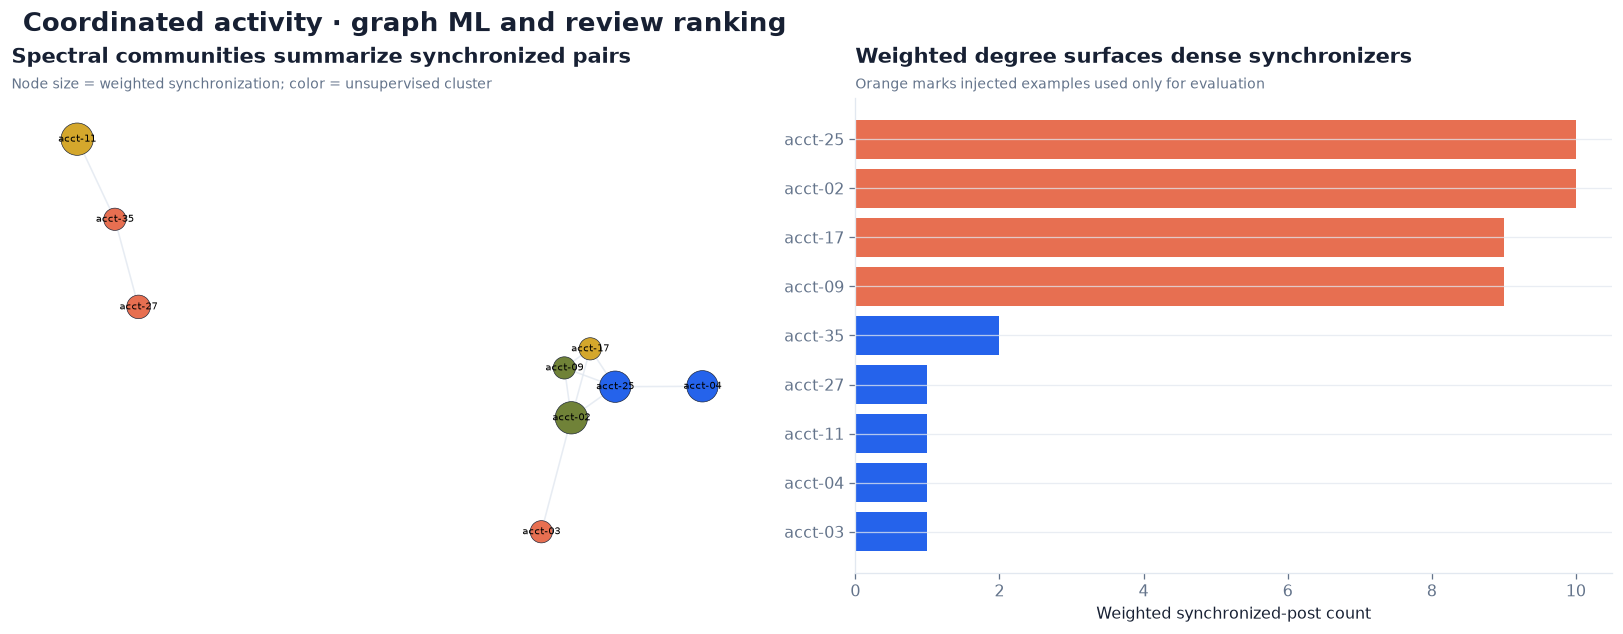

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, r2_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 88)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def compare_binary_models(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows, probabilities, fitted = [], {}, {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

import networkx as nx

coordination_graph = nx.Graph()
for row in pair_scores.itertuples(index=False):
    coordination_graph.add_edge(row.account_left, row.account_right, weight=float(row.synchronized_posts))
graph_nodes = sorted(coordination_graph.nodes())
weighted_adjacency = nx.to_numpy_array(coordination_graph, nodelist=graph_nodes, weight="weight")
degree = weighted_adjacency.sum(axis=1)
inv_sqrt_degree = np.diag(1 / np.sqrt(np.maximum(degree, 1)))
laplacian = np.eye(len(graph_nodes)) - inv_sqrt_degree @ weighted_adjacency @ inv_sqrt_degree
_, eigenvectors = np.linalg.eigh(laplacian)
graph_embedding = eigenvectors[:, 1:4]
graph_cluster = KMeans(n_clusters=4, n_init=30, random_state=SEED).fit_predict(graph_embedding)
node_table = pd.DataFrame({"account": graph_nodes, "spectral_cluster": graph_cluster, "weighted_degree": degree})
node_table["injected_coordination"] = node_table["account"].isin(coordinated_accounts).astype(int)

position = nx.spring_layout(coordination_graph, seed=SEED, weight="weight")
colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["orange"], PALETTE["olive"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), constrained_layout=True)
nx.draw_networkx_edges(coordination_graph, position, ax=axes[0], edge_color=PALETTE["grid"], alpha=0.8)
nx.draw_networkx_nodes(coordination_graph, position, ax=axes[0], node_color=[colors[value] for value in graph_cluster], node_size=170 + 24 * degree, edgecolors=PALETTE["ink"], linewidths=0.4)
nx.draw_networkx_labels(coordination_graph, position, ax=axes[0], font_size=6)
axes[0].set_title("Spectral communities summarize synchronized pairs", loc="left", pad=22)
axes[0].text(0, 1.02, "Node size = weighted synchronization; color = unsupervised cluster", transform=axes[0].transAxes, color=PALETTE["muted"], fontsize=9)
axes[0].axis("off")

ranked_nodes = node_table.nlargest(12, "weighted_degree").sort_values("weighted_degree")
bar_colors = [PALETTE["orange"] if value else PALETTE["blue"] for value in ranked_nodes["injected_coordination"]]
axes[1].barh(ranked_nodes["account"], ranked_nodes["weighted_degree"], color=bar_colors)
polish_axis(axes[1], "Weighted degree surfaces dense synchronizers", "Orange marks injected examples used only for evaluation", "Weighted synchronized-post count", "")
fig.suptitle("Coordinated activity · graph ML and review ranking", fontsize=16, fontweight="bold", x=0.01, ha="left")

injected_cluster_counts = node_table[node_table["injected_coordination"] == 1]["spectral_cluster"].value_counts()
print(node_table.groupby("spectral_cluster").agg(accounts=("account", "count"), mean_weighted_degree=("weighted_degree", "mean"), injected_examples=("injected_coordination", "sum")).round(2).to_string())
print("\nAnalyst takeaways:")
print(f"- The four injected accounts concentrate most in spectral cluster {int(injected_cluster_counts.idxmax())}.")
print("- Timing and content synchronization create review leads; they do not establish common control, identity, or intent.")
print("- Source-specific posting rates and reshare semantics are essential before operational interpretation.")


## Checks

Run deterministic integrity and reasonableness checks.


In [5]:
assert (pair_scores["account_left"] < pair_scores["account_right"]).all()
assert pair_scores["review_priority"].between(0, 1).all()
assert pair_scores["synchronized_posts"].max() >= 3
print("Checks passed; synchronization is a lead requiring content and context review.")


Checks passed; synchronization is a lead requiring content and context review.


## Next Steps

- Add source-specific rate baselines and reshare semantics.
- Review only public content allowed by source terms.
